# Data Wragling

Se nos ha pedido que limpiemos y procesemos un Dataset de Audio Books que nos permitan responder las siguientes preguntas:

1. ¿Cuál es la mediana de la duración del audiolibro en minutos?
2. ¿Cuántas valoraciones tiene el libro con mayor número de valoraciones?
3. ¿Cuál es el autor con un mayor número de libros?
4. ¿Y el Narrador más popular?

## 1. Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set options
pd.set_option('display.max_columns', None)

# set visualization style
sns.set_style('darkgrid')

In [2]:
# Load Data
data = pd.read_csv('../data/audio_book_data.csv')

data.head()

,name,author,narrator,time,releasedate,language,stars,price
0,Geronimo Stilton #11 & #12,Writtenby:GeronimoStilton,Narratedby:BillLobely,2 hrs and 20 mins,04-08-08,English,5 out of 5 stars34 ratings,468.00
1,The Burning Maze,Writtenby:RickRiordan,Narratedby:RobbieDaymond,13 hrs and 8 mins,01-05-18,English,4.5 out of 5 stars41 ratings,820.00
2,The Deep End,Writtenby:JeffKinney,Narratedby:DanRussell,2 hrs and 3 mins,06-11-20,English,4.5 out of 5 stars38 ratings,410.00
3,Daughter of the Deep,Writtenby:RickRiordan,Narratedby:SoneelaNankani,11 hrs and 16 mins,05-10-21,English,4.5 out of 5 stars12 ratings,615.00
4,"The Lightning Thief: Percy Jackson, Book 1",Writtenby:RickRiordan,Narratedby:JesseBernstein,10 hrs,13-01-10,English,4.5 out of 5 stars181 ratings,820.00


Para las preguntas planteadas, resulta necesario realizar una serie de transformaciones sobre las variables.

1. Para la primera pregunta, es necesario convertir la duración del audiolibro a minutos, por tanto vamos a trabajar con el campo `time` que se encuentra en string y describe con "hrs" y "mins" la cantidad de horas y minutos descritos en el campo. Para ello, haremos un split y vamos a extraer la cantidad de horas y minutos o simplemente filtrar todo aquello que sean números en un orden determinado.
2. hay que limpiar el stars, tambien se encuentran en formato string describiendo la cantidad de estrellas sobre la base de 5 y la cantidad de validaciones.
3. En este caso, debemos quedarnos con todo lo que este la derecha de "WrittenBy:" para quedarnos con el nombre del autor.
4. Para el narrador, debemos quedarnos con todo lo que este a la derecha de "NarratedBy:" para quedarnos con el nombre del narrador.

Intentaremos darle formato a los datos resultantes de la transformación para que sean más legibles y fáciles de interpretar.

## 2. Data Cleaning and Processing

Empezaremos con la transformación de los datos para cada una de las partes de la preguntas.

In [3]:
# Copy to transformation
df = data.copy()

In [4]:
df.sample(5)

,name,author,narrator,time,releasedate,language,stars,price
61938,Only Love Is Real,Writtenby:BrianL.WeissM.D.,Narratedby:BrianL.WeissM.D.,3 hrs and 8 mins,16-12-99,English,5 out of 5 stars56 ratings,500.00
55458,Las cenizas de Ángela [Angela's Ashes],Writtenby:FrankMcCourt,Narratedby:JorgeLemus,15 hrs and 23 mins,01-05-19,spanish,Not rated yet,"1,036.00"
50668,The Conqueror,Writtenby:AdityaIyengar,Narratedby:AvinashKumarSingh,6 hrs and 57 mins,10-06-20,English,4.5 out of 5 stars6 ratings,668.00
32019,"Curing the Incurable, 3rd Edition","Writtenby:ThomasE.LevyMDJD,Dr.GarryGordon",Narratedby:StephenR.Thorne,13 hrs and 40 mins,03-07-18,English,1 out of 5 stars1 rating,703.00
50684,The Winter Guest,Writtenby:W.C.Ryan,Narratedby:LiamHourican,9 hrs and 5 mins,06-01-22,English,Not rated yet,"1,328.00"


### 2.1 Duración del audiolibro en minutos

In [5]:
def transform_time(time_str):

    import re
    hrs_pattern = re.match(r'(\d+)\s*hrs?.*?', time_str)
    mins_pattern = re.match(r'.*?(\d+)\s*mins?', time_str)
    hrs = int(hrs_pattern.group(1)) if hrs_pattern else 0
    mins = int(mins_pattern.group(1)) if mins_pattern else 0

    return hrs * 60 + mins

df['time_minutes'] = df['time'].apply(transform_time)


### 2.2 Número de Valoraciones

In [6]:
def transform_n_reviews(stars_str):
    import re
    pattern = re.match(r'.*?(\d+)\s*ratings', stars_str)
    return int(pattern.group(1)) if pattern else 0

df['n_reviews'] = df['stars'].apply(transform_n_reviews)

### 2.3 Clean Authot and Narrator

In [7]:
def clean_author_narrator(field_str, prefix):
    import re
    pattern = re.match(rf'{prefix}:\s*(.*)', field_str)
    name = pattern.group(1).strip() if pattern else None
    # Insert withespace between lowercase and uppercase letters
    name = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', name) if name else None
    return name

df['author_clean'] = df['author'].apply(lambda x: clean_author_narrator(x, "Writtenby"))
df['narrator_clean'] = df['narrator'].apply(lambda x: clean_author_narrator(x, "Narratedby"))

Con esto ahora si podemos responder las preguntas planteadas. Damos por finalizada la transformación de datos y pasamos a la parte de análisis y visualización.

## Preguntas:

### a. ¿Cuál es la mediana de la duración del audiolibro en minutos?

Con realizar un calculo de la mediana sobre el campo de duración en minutos, podemos responder a esta pregunta. Para ello, podemos usar la función `median()` de pandas sobre el campo `duration_minutes` que hemos creado en la transformación de datos.

In [8]:
print( "The median duration of the audiobooks in minutes is:",
    df['time_minutes'].median(), "minutes"
)

The median duration of the audiobooks in minutes is: 386.0 minutes


### b. ¿Cuántas valoraciones tiene el libro con mayor número de valoraciones?

Esta vez hagamos un histograma facil para ver la cantidad de valoraciones en un top 10 libros.

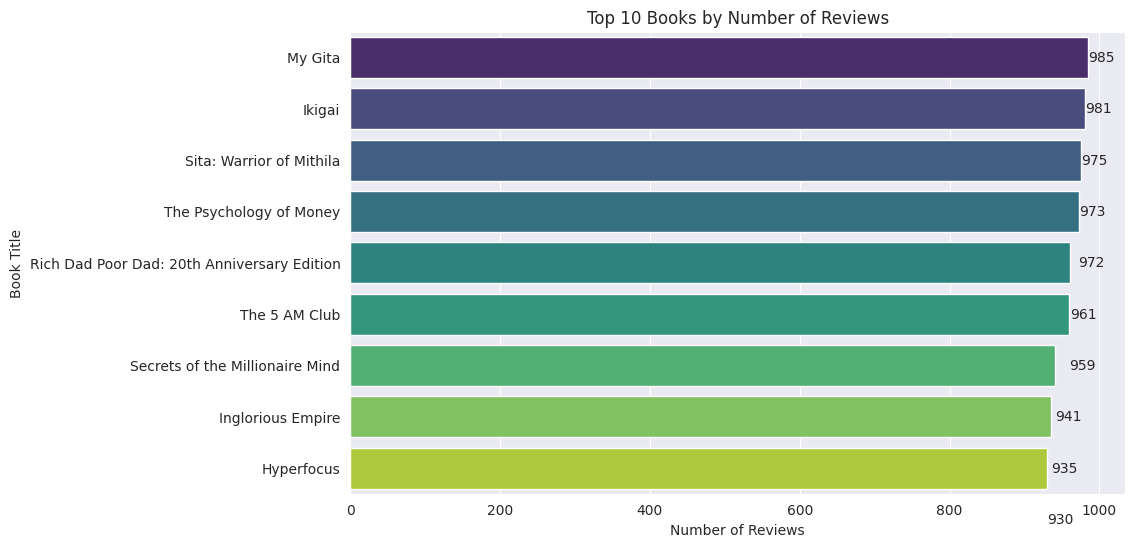

In [9]:
top_books = df.sort_values(by='n_reviews', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='n_reviews', y='name', data=top_books, palette='viridis', hue = 'name')
## Adding labels over bars
for index, value in enumerate(top_books['n_reviews']):
    plt.text(value, index, str(value), va='center')
plt.title('Top 10 Books by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Book Title')
plt.show()

El libro con la mayor cantidad de valoraciones es "My Gita" con 985 valoraciones, de Devdutt Pattanaik y redactado por Vivek Madan.

### c. ¿Cuál es el autor con un mayor número de libros?

Podemos hacer un conteo con la misma metodologia.

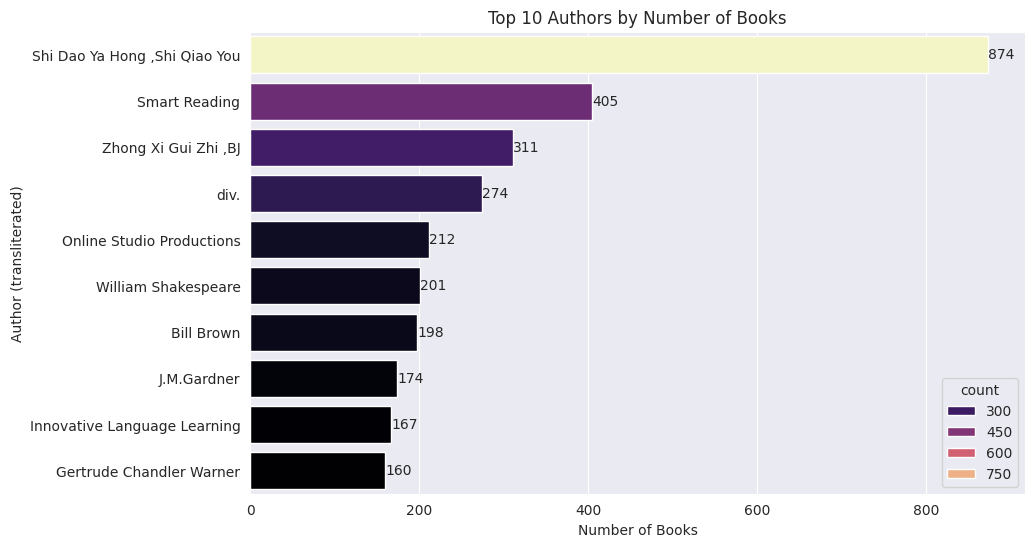

In [10]:
from unidecode import unidecode


def to_plot_label(author_name: str) -> str:
    """Transliterate non-Latin names to avoid missing glyph issues in plots."""
    author_name = str(author_name)
    if author_name.isascii():
        return author_name
    label = unidecode(author_name).strip()
    return label if label else author_name.encode('ascii', errors='ignore').decode('ascii')


top_authors = df['author_clean'].value_counts().head(10)

plot_df = pd.DataFrame({
    'author_original': top_authors.index,
    'count': top_authors.values,
})
plot_df['author_plot'] = plot_df['author_original'].map(to_plot_label)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='count', y='author_plot', palette='magma', hue='count')

# Add labels over bars.
for index, value in enumerate(plot_df['count']):
    plt.text(value, index, str(value), va='center')

plt.title('Top 10 Authors by Number of Books')
plt.xlabel('Number of Books')
plt.ylabel('Author (transliterated)')
plt.show()

El autor con la mayor cantidad de libros es "Shi Dao Ya Hong, Shi Qiao You", despues de haber pasado el string por un proceso de transliteración para convertir los caracteres chinos a caracteres latinos.

### d. ¿Y el Narrador más popular?

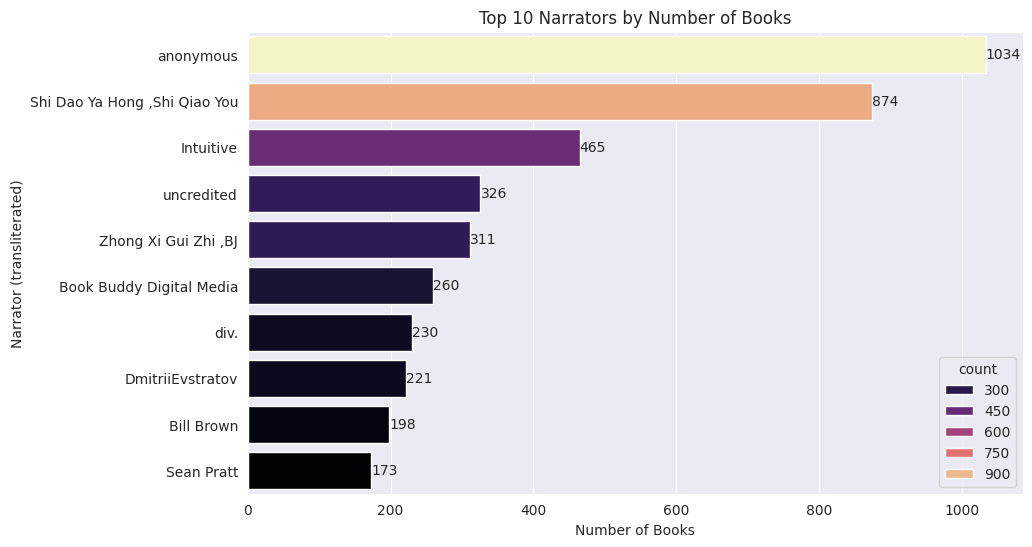

In [11]:
top_narrators = df['narrator_clean'].value_counts().head(10)

plot_df = pd.DataFrame({
    'narrator_original': top_narrators.index,
    'count': top_narrators.values,
})
plot_df['narrator_plot'] = plot_df['narrator_original'].map(to_plot_label)
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='count', y='narrator_plot', palette='magma', hue='count')

# Add labels over bars.
for index, value in enumerate(plot_df['count']):
    plt.text(value, index, str(value), va='center')

plt.title('Top 10 Narrators by Number of Books')
plt.xlabel('Number of Books')
plt.ylabel('Narrator (transliterated)')
plt.show()

El mayor narrador es Anónimo, pero seguido por el mismo "Shi Dao Ya Hong, Shi Qiao You".